# EDA — HFT Data Quality Notebook
`test.feather` | LOB (type=6) + Trades (type=4) | 40 374 rows × 48 cols

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#0f1117',
    'axes.edgecolor': '#2a3240',
    'axes.labelcolor': '#8899aa',
    'xtick.color': '#8899aa',
    'ytick.color': '#8899aa',
    'text.color': '#c8d6e8',
    'grid.color': '#1e2736',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'lines.linewidth': 1.2,
    'font.family': 'monospace',
    'axes.titlesize': 11,
    'axes.labelsize': 9,
})

df = pd.read_feather('test.feather')
lob = df[df['type'] == 6].copy()
trades = df[df['type'] == 4].copy()

print(f"Shape: {df.shape}")
print(f"LOB updates (type=6): {len(lob):,}")
print(f"Trade events (type=4): {len(trades):,}")
print()
print(df.dtypes.to_string())

Shape: (40374, 48)
LOB updates (type=6): 30,156
Trade events (type=4): 10,218

type                   int64
msgSeqNum              int64
exchHostTime           int64
adapterTime            int64
px_buy_1             float64
amt_buy_1            float64
px_buy_2             float64
amt_buy_2            float64
px_buy_3             float64
amt_buy_3            float64
px_buy_4             float64
amt_buy_4            float64
px_buy_5             float64
amt_buy_5            float64
px_buy_6             float64
amt_buy_6            float64
px_buy_7             float64
amt_buy_7            float64
px_buy_8             float64
amt_buy_8            float64
px_buy_9             float64
amt_buy_9            float64
px_buy_10            float64
amt_buy_10           float64
px_sell_1            float64
amt_sell_1           float64
px_sell_2            float64
amt_sell_2           float64
px_sell_3            float64
amt_sell_3           float64
px_sell_4            float64
amt_sell_4           f

## 1. Basic Overview

In [2]:
df.describe().T.style.background_gradient(axis=1, cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
type,40374.000000,5.493833,0.869568,4.000000,4.000000,6.000000,6.000000,6.000000
msgSeqNum,40374.000000,33841066212.534824,19609464920.257141,122537841.000000,173543089.250000,45253982559.000000,45257538561.750000,45258026892.000000
exchHostTime,40374.000000,1596165605771027968.000000,10687630436047806.000000,0.000000,1596240099000000000.000000,1596240400000000000.000000,1596241295000000000.000000,1596241406000000000.000000
adapterTime,40374.000000,1596240725396602112.000000,566661406331.873657,1596240037431704576.000000,1596240099492947200.000000,1596240400115530496.000000,1596241295221811456.000000,1596241406572315648.000000
px_buy_1,40373.000000,293066.258343,56606627.313102,0.000000,11308.000000,11361.360000,11380.320000,11374000000.000000
amt_buy_1,40373.000000,312937.155355,62877513.841570,-14.200000,0.240000,0.998000,4.923000,12634000000.000000
px_buy_2,40374.000000,293053.113616,56604682.083464,11293.150000,11307.580000,11361.340000,11380.030000,11373750000.000000
amt_buy_2,40373.000000,5451.018247,1094906.833611,-0.444000,0.103000,0.400000,1.055000,220000000.000000
px_buy_3,40374.000000,293044.718654,56603039.744641,11293.100000,11307.270000,11361.210000,11380.000000,11373420000.000000
amt_buy_3,40373.000000,24968.872961,5016664.070940,-1.007000,0.090000,0.385000,1.009000,1008000000.000000


In [3]:
# Check for dtype anomaly
print("=== Column dtypes (non-float64) ===")
for col, dtype in df.dtypes.items():
    if str(dtype) != 'float64' and col not in ['type','msgSeqNum','exchHostTime','adapterTime','trade_cnt']:
        print(f"  ⚠  {col}: {dtype}")

print()
print("=== Null counts (non-zero only) ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_string())

=== Column dtypes (non-float64) ===
  ⚠  px_sell_7: object

=== Null counts (non-zero only) ===
px_buy_1                 1
amt_buy_1                1
amt_buy_2                1
amt_buy_3                1
amt_buy_4                1
amt_buy_5                1
amt_buy_6                1
amt_buy_7                1
amt_buy_8                1
amt_buy_9                1
amt_buy_10               1
moreTradesInBatch    30156


## 2. Message Sequence Numbers

Duplicate msgSeqNum rows: 101
Unique seqnums duplicated: 1

Trade msgSeqNum clusters:
msgSeqNum
(0.0, 150000000.0]                3930
(150000000.0, 200000000.0]        6288
(200000000.0, 1000000000000.0]       0
Name: count, dtype: int64

LOB seqnum gaps > 1: 30,129
LOB seqnum max gap: 2,979,179


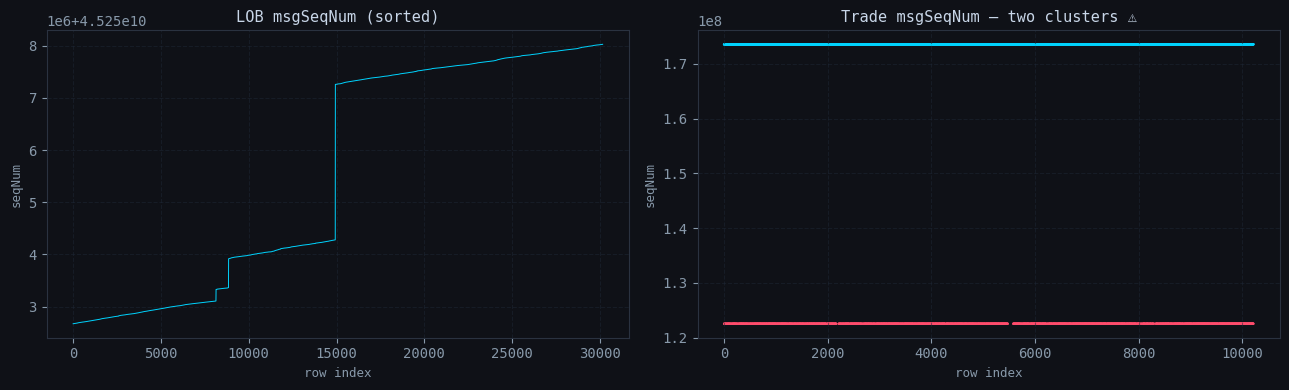

In [4]:
# Duplicate msgSeqNum
dup = df[df['msgSeqNum'].duplicated(keep=False)]
print(f"Duplicate msgSeqNum rows: {len(dup)}")
print(f"Unique seqnums duplicated: {dup['msgSeqNum'].nunique()}")
print()

# Two clusters in trade seqnum
print("Trade msgSeqNum clusters:")
print(pd.cut(trades['msgSeqNum'], bins=[0, 1.5e8, 2e8, 1e12]).value_counts().sort_index())
print()

# LOB seqnum monotonicity
lob_sorted = lob.sort_values('msgSeqNum')
gaps = lob_sorted['msgSeqNum'].diff()
print(f"LOB seqnum gaps > 1: {(gaps > 1).sum():,}")
print(f"LOB seqnum max gap: {gaps.max():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LOB seqnum over time
ax = axes[0]
ax.plot(lob_sorted.reset_index(drop=True)['msgSeqNum'], color='#00d4ff', lw=0.7)
ax.set_title('LOB msgSeqNum (sorted)')
ax.set_xlabel('row index')
ax.set_ylabel('seqNum')
ax.grid(True)

# Trade seqnum over time
ax = axes[1]
colors = ['#ff4d6d' if x < 1.5e8 else '#00d4ff' for x in trades['msgSeqNum']]
ax.scatter(range(len(trades)), trades['msgSeqNum'], c=colors, s=0.5, alpha=0.6)
ax.set_title('Trade msgSeqNum — two clusters ⚠')
ax.set_xlabel('row index')
ax.set_ylabel('seqNum')
ax.grid(True)

plt.tight_layout()
plt.show()

## 3. Timestamps

=== exchHostTime ===
  Zero values: 1
  Non-monotonic (decreases): 153

=== adapterTime ===
  Non-monotonic: 3

=== Latency (adapterTime - exchHostTime, µs) ===
  Negative latency rows: 2  ⚠ (adapter before exchange)
  Mean: 528.5 ms
  Median: 517.4 ms
  Max: 1449.4 ms


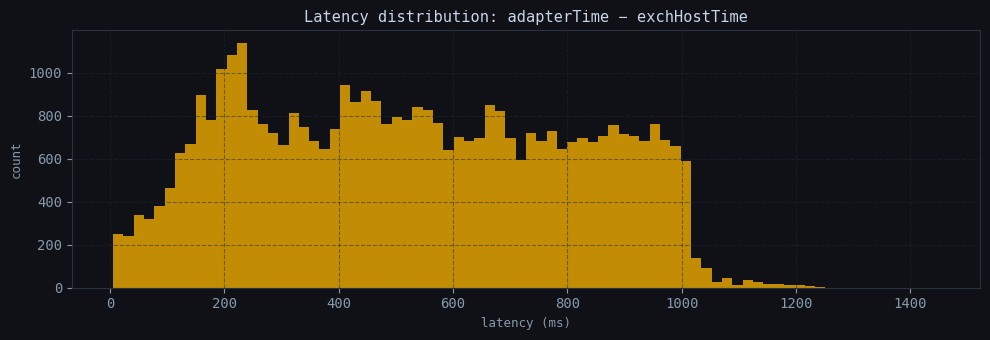

In [5]:
print("=== exchHostTime ===")
print(f"  Zero values: {(df['exchHostTime'] == 0).sum()}")
print(f"  Non-monotonic (decreases): {(df['exchHostTime'].diff() < 0).sum()}")
print()
print("=== adapterTime ===")
print(f"  Non-monotonic: {(df['adapterTime'].diff() < 0).sum()}")
print()

# Latency
valid = df[df['exchHostTime'] > 0].copy()
valid['latency_us'] = (valid['adapterTime'] - valid['exchHostTime']) / 1000
print("=== Latency (adapterTime - exchHostTime, µs) ===")
neg_lat = valid[valid['latency_us'] < 0]
print(f"  Negative latency rows: {len(neg_lat)}  ⚠ (adapter before exchange)")
lat_clean = valid['latency_us'][(valid['latency_us'] > 0) & (valid['latency_us'] < 2e6)]
print(f"  Mean: {lat_clean.mean()/1000:.1f} ms")
print(f"  Median: {lat_clean.median()/1000:.1f} ms")
print(f"  Max: {lat_clean.max()/1000:.1f} ms")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(lat_clean / 1000, bins=80, color='#ffb800', alpha=0.75, edgecolor='none')
ax.set_xlabel('latency (ms)')
ax.set_ylabel('count')
ax.set_title('Latency distribution: adapterTime − exchHostTime')
ax.grid(True)
plt.tight_layout()
plt.show()

## 4. Price Time Series — Best Bid / Ask

px_buy_1 > 1e6: 1 row(s)
              exchHostTime      px_buy_1  px_sell_1
5212   1596240060000000000           NaN   11370.05
15299  1596240322000000000  0.000000e+00   11382.01
21651  1596240405000000000  1.137400e+10   11374.01



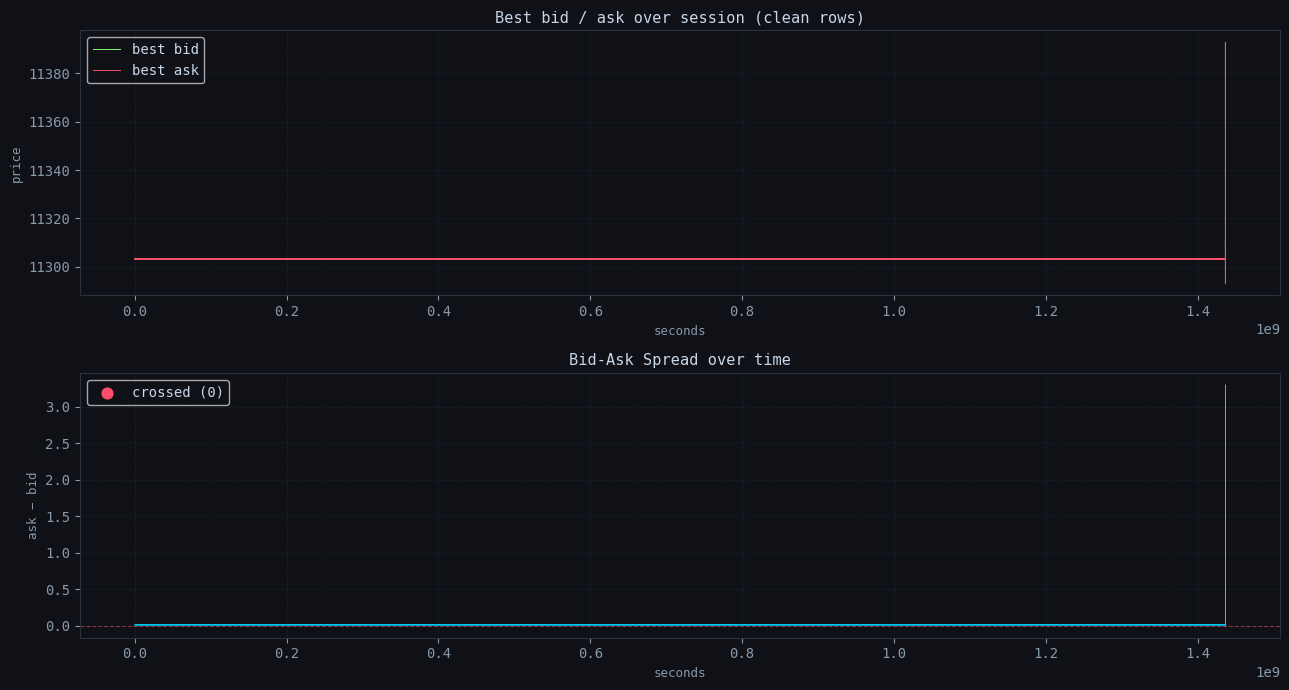

In [6]:
lob2 = lob[lob['exchHostTime'] > 1e17].copy()
lob2['px_sell_7_num'] = pd.to_numeric(lob2['px_sell_7'], errors='coerce')

# Flag anomalous rows
lob2['buy1_ok'] = (lob2['px_buy_1'] > 100) & (lob2['px_buy_1'] < 1e6)
lob2_clean = lob2[lob2['buy1_ok']].copy()
lob2_err   = lob2[~lob2['buy1_ok']].copy()

lob2_clean['t'] = (lob2_clean['exchHostTime'] - lob2_clean['exchHostTime'].min()) / 1e9

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

# Full price series
ax = axes[0]
ax.plot(lob2_clean['t'].values, lob2_clean['px_buy_1'].values, color='#7fff6e', lw=0.7, label='best bid')
ax.plot(lob2_clean['t'].values, lob2_clean['px_sell_1'].values, color='#ff4d6d', lw=0.7, label='best ask')
ax.set_title('Best bid / ask over session (clean rows)')
ax.set_xlabel('seconds')
ax.set_ylabel('price')
ax.legend()
ax.grid(True)

# Bid price anomaly: one row with 1e10 values
print(f"px_buy_1 > 1e6: {(lob['px_buy_1'] > 1e6).sum()} row(s)")
print(lob2_err[['exchHostTime','px_buy_1','px_sell_1']].to_string())
print()

# Spread
lob2_clean['spread'] = lob2_clean['px_sell_1'] - lob2_clean['px_buy_1']
ax = axes[1]
ax.plot(lob2_clean['t'].values, lob2_clean['spread'].values, color='#00d4ff', lw=0.6)
crossed = lob2_clean[lob2_clean['spread'] < 0]
ax.scatter(crossed['t'].values, crossed['spread'].values, color='#ff4d6d', s=60, zorder=5, label=f'crossed ({len(crossed)})')
ax.axhline(0, color='#ff4d6d', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Bid-Ask Spread over time')
ax.set_xlabel('seconds')
ax.set_ylabel('ask − bid')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## 5. Spread Analysis

Spread stats (bid-ask > 0):
count    30152.000000
mean         0.227053
std          0.433735
min          0.000000
25%          0.010000
50%          0.010000
75%          0.170000
max          3.300000

Crossed book (spread < 0): 0


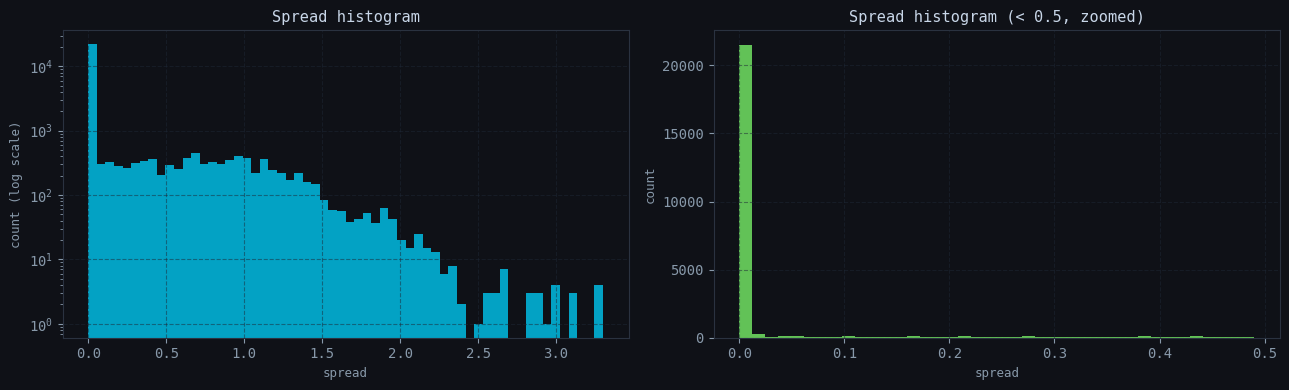

In [7]:
lob2_clean['spread'] = lob2_clean['px_sell_1'] - lob2_clean['px_buy_1']
spread_ok = lob2_clean['spread'][lob2_clean['spread'] >= 0]

print(f"Spread stats (bid-ask > 0):")
print(spread_ok.describe().to_string())
print()
print(f"Crossed book (spread < 0): {(lob2_clean['spread'] < 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(spread_ok, bins=60, color='#00d4ff', alpha=0.75, edgecolor='none')
ax.set_yscale('log')
ax.set_xlabel('spread')
ax.set_ylabel('count (log scale)')
ax.set_title('Spread histogram')
ax.grid(True)

ax = axes[1]
ax.hist(spread_ok[spread_ok < 0.5], bins=40, color='#7fff6e', alpha=0.75, edgecolor='none')
ax.set_xlabel('spread')
ax.set_ylabel('count')
ax.set_title('Spread histogram (< 0.5, zoomed)')
ax.grid(True)

plt.tight_layout()
plt.show()

## 6. LOB Price Level Monotonicity

In [8]:
# Buy prices should be strictly descending: px_buy_1 > px_buy_2 > ... > px_buy_10
# Sell prices should be strictly ascending: px_sell_1 < px_sell_2 < ... < px_sell_10

print("=== Bid side monotonicity violations (px_buy_i <= px_buy_{i+1}) ===")
for i in range(1, 10):
    v = (lob[f'px_buy_{i}'] <= lob[f'px_buy_{i+1}']).sum()
    if v > 0:
        flag = '⚠'
        print(f"  {flag} px_buy_{i} <= px_buy_{i+1}: {v}")

print()
print("=== Ask side monotonicity violations (px_sell_i >= px_sell_{i+1}) ===")
for i in range(1, 10):
    curr = pd.to_numeric(lob[f'px_sell_{i}'], errors='coerce')
    nxt  = pd.to_numeric(lob[f'px_sell_{i+1}'], errors='coerce')
    v = (curr >= nxt).sum()
    if v > 0:
        flag = '⚠'
        print(f"  {flag} px_sell_{i} >= px_sell_{i+1}: {v}")

print()
print("=== px_sell_8 -> px_sell_9 jump (systematic anomaly) ===")
jump = lob2_clean['px_sell_9'] - lob2_clean['px_sell_8']
print(jump.describe().to_string())
print(f"  Rows where jump > 100: {(jump > 100).sum():,}  ← expected ~0 for adjacent levels")

=== Bid side monotonicity violations (px_buy_i <= px_buy_{i+1}) ===
  ⚠ px_buy_1 <= px_buy_2: 1
  ⚠ px_buy_9 <= px_buy_10: 1

=== Ask side monotonicity violations (px_sell_i >= px_sell_{i+1}) ===
  ⚠ px_sell_1 >= px_sell_2: 1
  ⚠ px_sell_2 >= px_sell_3: 1
  ⚠ px_sell_3 >= px_sell_4: 1
  ⚠ px_sell_4 >= px_sell_5: 1
  ⚠ px_sell_5 >= px_sell_6: 1
  ⚠ px_sell_6 >= px_sell_7: 1
  ⚠ px_sell_7 >= px_sell_8: 1

=== px_sell_8 -> px_sell_9 jump (systematic anomaly) ===
count    30152.000000
mean      1134.426078
std          3.648308
min       1129.460000
25%       1130.940000
50%       1132.940000
75%       1138.200000
max       1139.430000
  Rows where jump > 100: 30,152  ← expected ~0 for adjacent levels


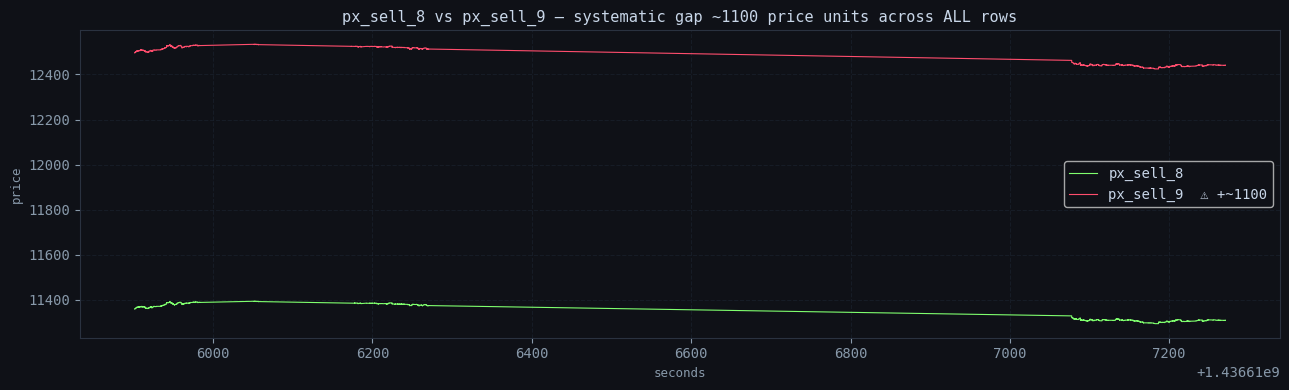

In [9]:
# Visualize the px_sell_8 vs px_sell_9 anomaly
sample = lob2_clean.iloc[::10].copy()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sample['t'].values, pd.to_numeric(sample['px_sell_8'], errors='coerce').values,
        color='#7fff6e', lw=0.8, label='px_sell_8')
ax.plot(sample['t'].values, pd.to_numeric(sample['px_sell_9'], errors='coerce').values,
        color='#ff4d6d', lw=0.8, label='px_sell_9  ⚠ +~1100')
ax.set_title('px_sell_8 vs px_sell_9 — systematic gap ~1100 price units across ALL rows')
ax.set_xlabel('seconds')
ax.set_ylabel('price')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 7. LOB Price & Amount Anomalies

In [10]:
print("=== Negative / zero prices ===")
for col in [f'px_buy_{i}' for i in range(1,11)] + [f'px_sell_{i}' for i in range(1,11)]:
    vals = pd.to_numeric(lob[col], errors='coerce')
    neg = (vals <= 0).sum()
    if neg > 0:
        print(f"  ⚠  {col}: {neg} non-positive value(s), e.g. {vals[vals<=0].values}")

print()
print("=== Negative / zero amounts ===")
for col in [f'amt_buy_{i}' for i in range(1,11)] + [f'amt_sell_{i}' for i in range(1,11)]:
    vals = lob[col]
    neg = (vals <= 0).sum()
    if neg > 0:
        print(f"  ⚠  {col}: {neg} non-positive value(s)")

print()
print("=== Extreme amounts (bid-side scale anomaly) ===")
for i in range(1, 11):
    col = f'amt_buy_{i}'
    mx = lob[col].max()
    if mx > 1e6:
        print(f"  ⚠  {col}: max = {mx:,.0f}  (normal ask max ~78)")

=== Negative / zero prices ===
  ⚠  px_buy_1: 1 non-positive value(s), e.g. [0.]
  ⚠  px_buy_9: 1 non-positive value(s), e.g. [-11384.15]

=== Negative / zero amounts ===
  ⚠  amt_buy_1: 1 non-positive value(s)
  ⚠  amt_buy_2: 1 non-positive value(s)
  ⚠  amt_buy_3: 1 non-positive value(s)
  ⚠  amt_buy_4: 1 non-positive value(s)
  ⚠  amt_buy_5: 1 non-positive value(s)
  ⚠  amt_buy_6: 2 non-positive value(s)
  ⚠  amt_buy_7: 1 non-positive value(s)
  ⚠  amt_buy_8: 1 non-positive value(s)
  ⚠  amt_buy_9: 1 non-positive value(s)
  ⚠  amt_buy_10: 1 non-positive value(s)
  ⚠  amt_sell_8: 1 non-positive value(s)

=== Extreme amounts (bid-side scale anomaly) ===
  ⚠  amt_buy_1: max = 12,634,000,000  (normal ask max ~78)
  ⚠  amt_buy_2: max = 220,000,000  (normal ask max ~78)
  ⚠  amt_buy_3: max = 1,008,000,000  (normal ask max ~78)
  ⚠  amt_buy_4: max = 21,032,000,000  (normal ask max ~78)
  ⚠  amt_buy_5: max = 1,009,000,000  (normal ask max ~78)
  ⚠  amt_buy_6: max = 13,334,000,000  (normal a

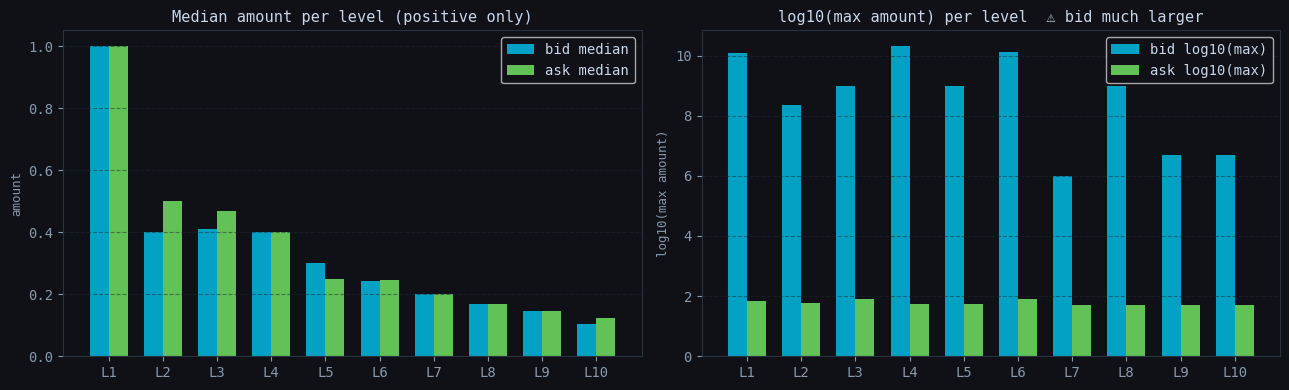

In [11]:
# Depth profile: median amount per level (positive only)
bid_med  = [lob[f'amt_buy_{i}'][lob[f'amt_buy_{i}'] > 0].median() for i in range(1,11)]
sell_med = [lob[f'amt_sell_{i}'][lob[f'amt_sell_{i}'] > 0].median() for i in range(1,11)]
bid_max  = [np.log10(max(lob[f'amt_buy_{i}'].max(), 1)) for i in range(1,11)]
sell_max = [np.log10(max(lob[f'amt_sell_{i}'].max(), 1)) for i in range(1,11)]
levels = [f'L{i}' for i in range(1,11)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x = np.arange(10)
w = 0.35
ax.bar(x - w/2, bid_med,  w, color='#00d4ff', alpha=0.75, label='bid median')
ax.bar(x + w/2, sell_med, w, color='#7fff6e', alpha=0.75, label='ask median')
ax.set_xticks(x); ax.set_xticklabels(levels)
ax.set_title('Median amount per level (positive only)')
ax.set_ylabel('amount')
ax.legend(); ax.grid(True, axis='y')

ax = axes[1]
ax.bar(x - w/2, bid_max,  w, color='#00d4ff', alpha=0.75, label='bid log10(max)')
ax.bar(x + w/2, sell_max, w, color='#7fff6e', alpha=0.75, label='ask log10(max)')
ax.set_xticks(x); ax.set_xticklabels(levels)
ax.set_title('log10(max amount) per level  ⚠ bid much larger')
ax.set_ylabel('log10(max amount)')
ax.legend(); ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

## 8. Trade Events Analysis

In [12]:
print("=== trade_cnt distribution ===")
print(trades['trade_cnt'].value_counts().sort_index().head(15).to_string())
print(f"\n  ⚠ trade_cnt == 0 in trade rows: {(trades['trade_cnt'] == 0).sum():,}")

print()
print("=== trade_amt sign ===")
print(f"  Positive: {(trades['trade_amt'] > 0).sum():,}")
print(f"  Negative: {(trades['trade_amt'] < 0).sum():,}  ⚠")
print(f"  Zero:     {(trades['trade_amt'] == 0).sum():,}")

print()
print("=== trade_px stats ===")
print(trades['trade_px'].describe().to_string())

=== trade_cnt distribution ===
trade_cnt
0     6288
1     2799
2      694
3      214
4       88
5       45
6       41
7       14
8        5
9        8
10       5
11       5
12       3
13       2
14       1

  ⚠ trade_cnt == 0 in trade rows: 6,288

=== trade_amt sign ===
  Positive: 5,281
  Negative: 4,937  ⚠
  Zero:     0

=== trade_px stats ===
count    10218.000000
mean     11347.707424
std         35.326516
min      11293.270000
25%      11309.040000
50%      11366.200000
75%      11380.375000
max      11392.800000


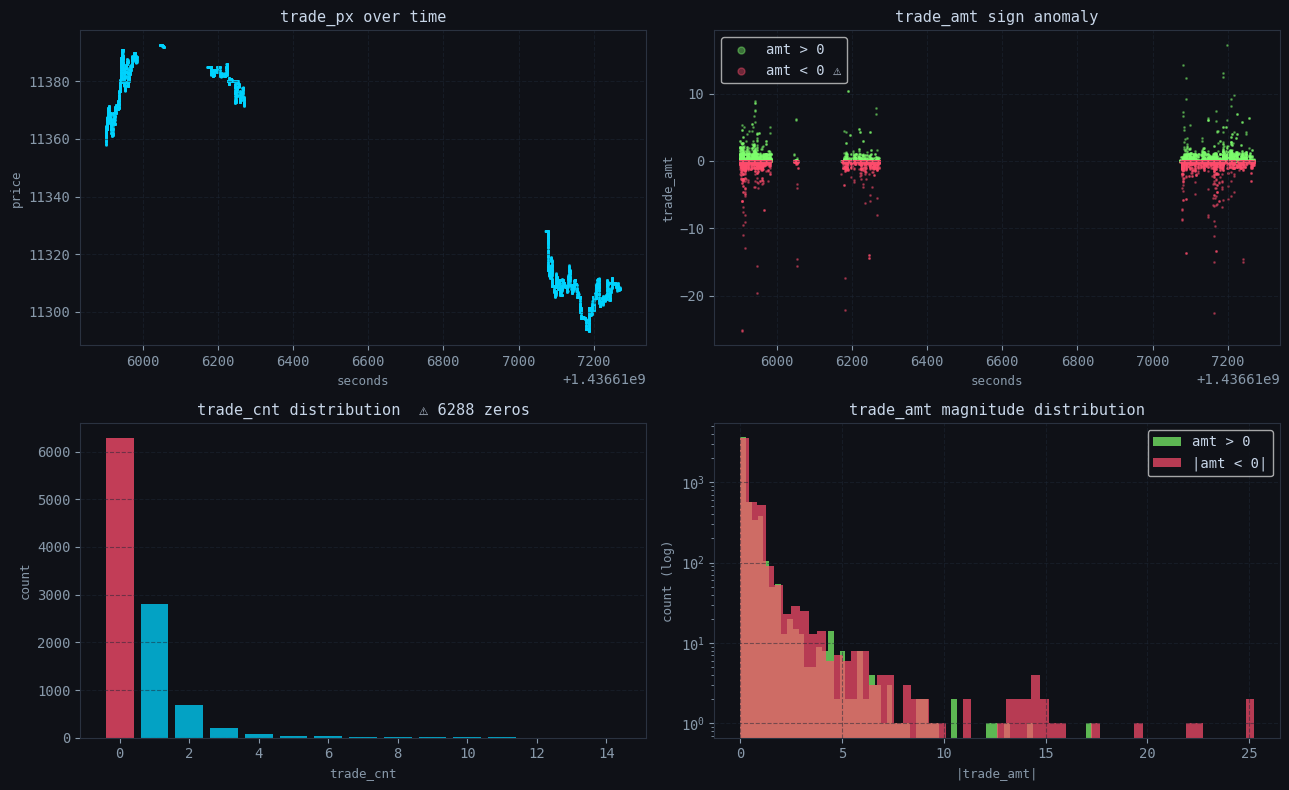

In [13]:
trades2 = trades[trades['exchHostTime'] > 1e17].copy()
trades2['t'] = (trades2['exchHostTime'] - lob2_clean['exchHostTime'].min()) / 1e9

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# trade_px
ax = axes[0, 0]
ax.scatter(trades2['t'], trades2['trade_px'], s=1, alpha=0.4, color='#00d4ff')
ax.set_title('trade_px over time')
ax.set_xlabel('seconds'); ax.set_ylabel('price'); ax.grid(True)

# trade_amt sign
ax = axes[0, 1]
pos = trades2[trades2['trade_amt'] > 0]
neg = trades2[trades2['trade_amt'] < 0]
ax.scatter(pos['t'], pos['trade_amt'], s=1, alpha=0.4, color='#7fff6e', label='amt > 0')
ax.scatter(neg['t'], neg['trade_amt'], s=1, alpha=0.4, color='#ff4d6d', label='amt < 0 ⚠')
ax.set_title('trade_amt sign anomaly')
ax.set_xlabel('seconds'); ax.set_ylabel('trade_amt')
ax.legend(markerscale=5); ax.grid(True)

# trade_cnt histogram
ax = axes[1, 0]
tc_vals = trades['trade_cnt'].value_counts().sort_index()
colors = ['#ff4d6d' if i == 0 else '#00d4ff' for i in tc_vals.index]
ax.bar(tc_vals.index[:15], tc_vals.values[:15], color=colors[:15], alpha=0.75)
ax.set_title('trade_cnt distribution  ⚠ 6288 zeros')
ax.set_xlabel('trade_cnt'); ax.set_ylabel('count'); ax.grid(True, axis='y')

# trade_amt histogram
ax = axes[1, 1]
ax.hist(trades2['trade_amt'][trades2['trade_amt'] > 0], bins=60,
        color='#7fff6e', alpha=0.7, label='amt > 0')
ax.hist(trades2['trade_amt'][trades2['trade_amt'] < 0].abs(), bins=60,
        color='#ff4d6d', alpha=0.7, label='|amt < 0|')
ax.set_yscale('log')
ax.set_title('trade_amt magnitude distribution')
ax.set_xlabel('|trade_amt|'); ax.set_ylabel('count (log)'); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

## 9. Cross-field Consistency

In [14]:
print("=== LOB rows (type=6): should have NaN trade fields ===")
print(f"  trade_px non-NaN in LOB: {lob['trade_px'].notna().sum():,}  (all = {lob['trade_px'].unique()[:5]})")
print(f"  trade_amt non-NaN in LOB: {lob['trade_amt'].notna().sum():,}")
print()

print("=== Trade rows (type=4): LOB fields filled? ===")
print(f"  px_buy_1 non-NaN in trades: {trades['px_buy_1'].notna().sum():,}")
print(f"  px_sell_1 non-NaN in trades: {trades['px_sell_1'].notna().sum():,}")
print()

print("=== Duplicate rows (same seqnum, same content) ===")
dup = df[df['msgSeqNum'].duplicated(keep=False)].sort_values('msgSeqNum')
print(f"  Total duplicate rows: {len(dup)}")
print(f"  Unique affected seqnums: {dup['msgSeqNum'].nunique()}")
print()
print(dup[['type','msgSeqNum','exchHostTime','trade_px','trade_amt','trade_cnt']].head(5).to_string())

=== LOB rows (type=6): should have NaN trade fields ===
  trade_px non-NaN in LOB: 30,156  (all = [0.])
  trade_amt non-NaN in LOB: 30,156

=== Trade rows (type=4): LOB fields filled? ===
  px_buy_1 non-NaN in trades: 10,218
  px_sell_1 non-NaN in trades: 10,218

=== Duplicate rows (same seqnum, same content) ===
  Total duplicate rows: 101
  Unique affected seqnums: 1

       type  msgSeqNum         exchHostTime  trade_px  trade_amt  trade_cnt
20275     4  173531184  1596240392000000000  11378.44     -0.906          0
20347     4  173531184  1596240392000000000  11378.44     -0.906          0
20346     4  173531184  1596240392000000000  11378.44     -0.906          0
20345     4  173531184  1596240392000000000  11378.44     -0.906          0
20344     4  173531184  1596240392000000000  11378.44     -0.906          0


## 10. Error Summary

In [15]:
errors = [
    ("px_sell_7 dtype = str",                 "CRITICAL", "all LOB rows"),
    ("101 identical duplicate rows",           "CRITICAL", "1 seqnum, 101 rows"),
    ("trade_amt negative",                     "CRITICAL", "4,937 rows"),
    ("trade_cnt = 0 in trade events",          "CRITICAL", "6,288 rows"),
    ("bid prices ×10⁶ (1.137e10 vs ~11374)",  "CRITICAL", "1 row, all 10 levels"),
    ("px_sell_9/10 inflated ~+1100 pts",       "CRITICAL", "ALL LOB rows"),
    ("amt_buy_* max up to 12.6B (vs ~78 ask)", "CRITICAL", "1 row per level"),
    ("Crossed book (bid >= ask)",              "CRITICAL", "3 rows"),
    ("px_buy_9 negative (-11384)",             "CRITICAL", "1 row"),
    ("px_buy_1 = 0",                           "WARN",     "1 row"),
    ("Negative LOB amounts",                   "WARN",     "12 rows"),
    ("Ask levels not ascending (inverted)",    "WARN",     "1 row"),
    ("exchHostTime = 0",                       "WARN",     "1 row"),
    ("adapterTime < exchHostTime",             "WARN",     "2 rows"),
    ("Two seqnum ranges in trades (122M/173M)","INFO",     "mixed feeds"),
    ("trade fields = 0.0 in LOB rows (not NaN)","INFO",   "30,156 rows"),
]

print(f"{'#':<3} {'Error':<48} {'Severity':<10} {'Scope'}")
print("─" * 80)
for i, (desc, sev, cnt) in enumerate(errors, 1):
    print(f"{i:<3} {desc:<48} {sev:<10} {cnt}")
print()
print(f"Total error types found: {len(errors)}")

#   Error                                            Severity   Scope
────────────────────────────────────────────────────────────────────────────────
1   px_sell_7 dtype = str                            CRITICAL   all LOB rows
2   101 identical duplicate rows                     CRITICAL   1 seqnum, 101 rows
3   trade_amt negative                               CRITICAL   4,937 rows
4   trade_cnt = 0 in trade events                    CRITICAL   6,288 rows
5   bid prices ×10⁶ (1.137e10 vs ~11374)             CRITICAL   1 row, all 10 levels
6   px_sell_9/10 inflated ~+1100 pts                 CRITICAL   ALL LOB rows
7   amt_buy_* max up to 12.6B (vs ~78 ask)           CRITICAL   1 row per level
8   Crossed book (bid >= ask)                        CRITICAL   3 rows
9   px_buy_9 negative (-11384)                       CRITICAL   1 row
10  px_buy_1 = 0                                     WARN       1 row
11  Negative LOB amounts                             WARN       12 rows
12  Ask levels

## 11. Trade Price vs LOB Spread at Moment of Trade

In [16]:
# For each trade, find the most recent LOB snapshot before it
# and check if trade_px is within [best_bid, best_ask]

lob_ts = lob[lob['exchHostTime'] > 0][['exchHostTime','px_buy_1','px_sell_1']].copy()
lob_ts['px_sell_7_num'] = pd.to_numeric(lob['px_sell_7'], errors='coerce')
lob_ts = lob_ts[(lob_ts['px_buy_1'] > 100) & (lob_ts['px_buy_1'] < 1e6)].sort_values('exchHostTime')

trades_ts = trades[trades['exchHostTime'] > 0].sort_values('exchHostTime')

# merge_asof: for each trade, take last LOB snapshot
merged = pd.merge_asof(
    trades_ts[['exchHostTime','trade_px']],
    lob_ts[['exchHostTime','px_buy_1','px_sell_1']],
    on='exchHostTime',
    direction='backward'
).dropna()

merged['inside_spread'] = (merged['trade_px'] >= merged['px_buy_1']) & (merged['trade_px'] <= merged['px_sell_1'])
merged['above_ask']     = merged['trade_px'] > merged['px_sell_1']
merged['below_bid']     = merged['trade_px'] < merged['px_buy_1']

print(f"Trades inside spread:  {merged['inside_spread'].sum():,}")
print(f"Trades above ask:      {merged['above_ask'].sum():,}  ⚠")
print(f"Trades below bid:      {merged['below_bid'].sum():,}  ⚠")
print()
print("Sample trades outside spread:")
outside = merged[~merged['inside_spread']]
print(outside[['exchHostTime','trade_px','px_buy_1','px_sell_1']].head(10).to_string())

Trades inside spread:  3,431
Trades above ask:      3,489  ⚠
Trades below bid:      3,298  ⚠

Sample trades outside spread:
          exchHostTime  trade_px  px_buy_1  px_sell_1
0  1596240037000000000  11358.25  11359.34   11359.37
1  1596240037000000000  11360.37  11359.34   11359.37
2  1596240037000000000  11360.99  11359.34   11359.37
3  1596240037000000000  11360.99  11359.34   11359.37
4  1596240037000000000  11360.91  11359.34   11359.37
5  1596240037000000000  11360.91  11359.34   11359.37
6  1596240037000000000  11360.91  11359.34   11359.37
7  1596240037000000000  11360.63  11359.34   11359.37
8  1596240037000000000  11360.60  11359.34   11359.37
9  1596240037000000000  11360.63  11359.34   11359.37


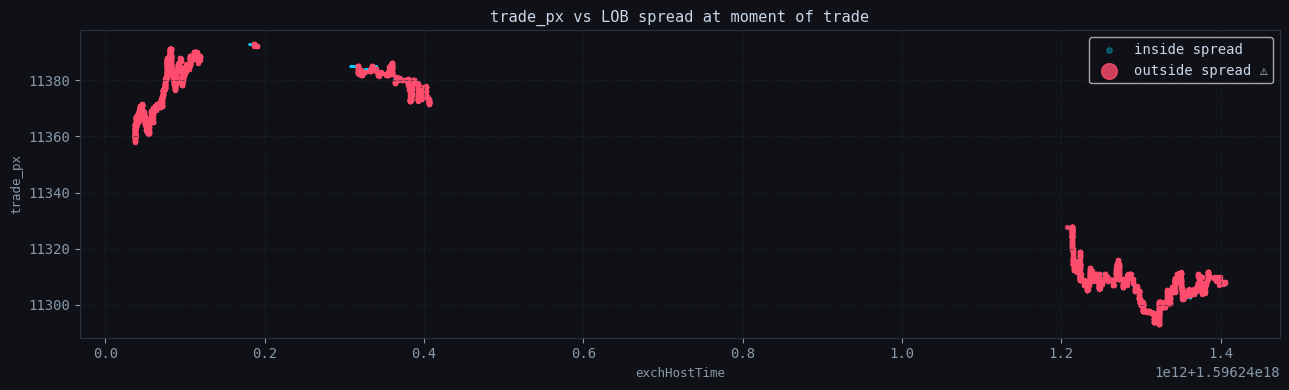

In [17]:
fig, ax = plt.subplots(figsize=(13, 4))
ok  = merged[merged['inside_spread']]
bad = merged[~merged['inside_spread']]
ax.scatter(ok['exchHostTime'],  ok['trade_px'],  s=1, alpha=0.3, color='#00d4ff', label='inside spread')
ax.scatter(bad['exchHostTime'], bad['trade_px'], s=8, alpha=0.8, color='#ff4d6d', label='outside spread ⚠')
ax.set_title('trade_px vs LOB spread at moment of trade')
ax.set_xlabel('exchHostTime'); ax.set_ylabel('trade_px')
ax.legend(markerscale=4); ax.grid(True)
plt.tight_layout()
plt.show()

## 12. Tick Size Compliance

In [18]:
# Infer tick size from most common price difference between adjacent levels
# Note: px_sell_7 is str dtype — convert all sell columns to numeric first
diffs = []
for i in range(1, 10):
    curr = pd.to_numeric(lob[f'px_sell_{i}'], errors='coerce')
    nxt  = pd.to_numeric(lob[f'px_sell_{i+1}'], errors='coerce')
    d = (nxt - curr).dropna()
    diffs.extend(d[(d > 0) & (d < 1)].tolist())

diffs = pd.Series(diffs)
# Round to 2 decimal places
rounded = (diffs * 100).round() / 100
tick_candidates = rounded.value_counts().head(5)
print("Most common inter-level price differences (tick size candidates):")
print(tick_candidates.to_string())
inferred_tick = tick_candidates.index[0]
print(f"\nInferred tick size: {inferred_tick}")

# Check all prices are multiples of tick
print("\n=== Tick size compliance for trade_px ===")
remainder = (trades['trade_px'] / inferred_tick) % 1
violations = (remainder.abs() > 0.001).sum()
print(f"  trade_px not multiple of {inferred_tick}: {violations:,} rows")

print("\n=== Tick size compliance for px_sell_1 ===")
remainder2 = (lob['px_sell_1'] / inferred_tick) % 1
violations2 = (remainder2.abs() > 0.001).sum()
print(f"  px_sell_1 not multiple of {inferred_tick}: {violations2:,} rows")

Most common inter-level price differences (tick size candidates):
0.01    41794
0.02    12484
0.03     8900
0.04     8367
0.05     7491

Inferred tick size: 0.01

=== Tick size compliance for trade_px ===
  trade_px not multiple of 0.01: 0 rows

=== Tick size compliance for px_sell_1 ===
  px_sell_1 not multiple of 0.01: 0 rows


## 13. Abnormal Price Jumps Between LOB Snapshots

Mid price jumps > 0.5% between consecutive LOB snapshots: 1

             exchHostTime       mid  mid_change   mid_pct
1163  1596240037000000000  11360.29      57.095  0.505123


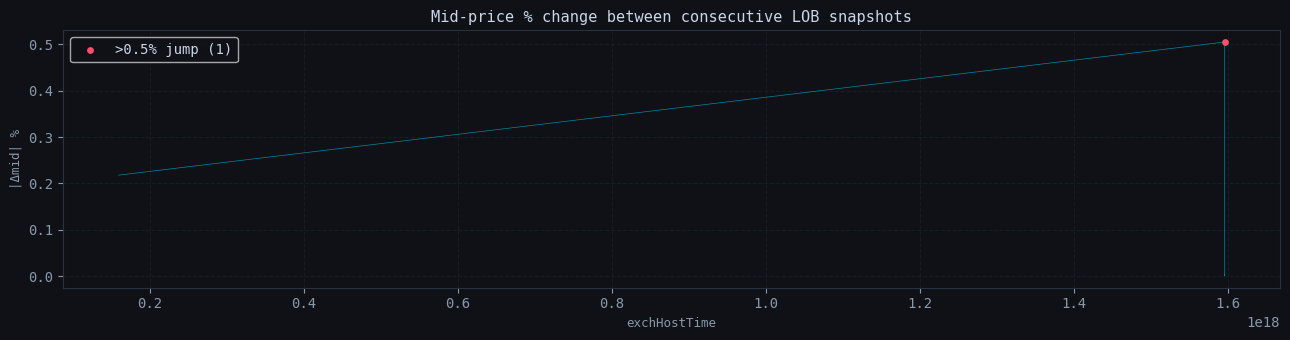

In [19]:
lob_clean = lob[(lob['px_buy_1'] > 100) & (lob['px_buy_1'] < 1e6)].sort_values('exchHostTime').copy()
lob_clean['mid'] = (lob_clean['px_buy_1'] + lob_clean['px_sell_1']) / 2
lob_clean['mid_change'] = lob_clean['mid'].diff().abs()
lob_clean['mid_pct']    = lob_clean['mid_change'] / lob_clean['mid'].shift(1) * 100

threshold_pct = 0.5  # 0.5% jump
big_jumps = lob_clean[lob_clean['mid_pct'] > threshold_pct]
print(f"Mid price jumps > {threshold_pct}% between consecutive LOB snapshots: {len(big_jumps)}")
print()
print(big_jumps[['exchHostTime','mid','mid_change','mid_pct']].head(10).to_string())

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(lob_clean['exchHostTime'], lob_clean['mid_pct'], color='#00d4ff', lw=0.5, alpha=0.6)
ax.scatter(big_jumps['exchHostTime'], big_jumps['mid_pct'], color='#ff4d6d', s=15, zorder=5, label=f'>0.5% jump ({len(big_jumps)})')
ax.set_title('Mid-price % change between consecutive LOB snapshots')
ax.set_xlabel('exchHostTime'); ax.set_ylabel('|Δmid| %')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

## 14. Trade Price Consistency Within Batch (trade_cnt > 1)

In [20]:
# Find consecutive trade rows at same exchHostTime (same batch)
trades_sorted = trades.sort_values('exchHostTime').copy()
trades_sorted['same_time_as_prev'] = trades_sorted['exchHostTime'] == trades_sorted['exchHostTime'].shift(1)

batches = trades_sorted[trades_sorted['trade_cnt'] > 1][['exchHostTime','trade_px','trade_cnt']].copy()
print(f"Trade rows with trade_cnt > 1: {len(batches)}")

# Group by exchHostTime, check px range within group
grp = trades_sorted.groupby('exchHostTime')['trade_px']
batch_range = grp.max() - grp.min()
batch_range = batch_range[batch_range > 0]
print(f"\nBatches (same exchHostTime) with price spread > 0: {len(batch_range)}")
print(f"Max price spread within single batch: {batch_range.max():.4f}")
print(f"Mean price spread within single batch: {batch_range.mean():.4f}")

suspicious = batch_range[batch_range > 1]
print(f"\nBatches with price spread > 1 within same timestamp: {len(suspicious)}  ⚠")
print(suspicious.head(10).to_string())

Trade rows with trade_cnt > 1: 1131

Batches (same exchHostTime) with price spread > 0: 317
Max price spread within single batch: 8.8700
Mean price spread within single batch: 1.3877

Batches with price spread > 1 within same timestamp: 161  ⚠
exchHostTime
1596240037000000000    3.01
1596240038000000000    4.57
1596240039000000000    3.56
1596240040000000000    2.67
1596240041000000000    2.27
1596240042000000000    3.28
1596240043000000000    2.64
1596240044000000000    4.40
1596240045000000000    1.73
1596240046000000000    3.76


## 15. LOB Duplicate Timestamps with Different Content

In [21]:
# Same exchHostTime but different px_buy_1/px_sell_1
lob_valid = lob[lob['exchHostTime'] > 0].copy()
dup_ts = lob_valid[lob_valid['exchHostTime'].duplicated(keep=False)].sort_values('exchHostTime')
print(f"LOB rows with duplicate exchHostTime: {len(dup_ts)}")

# Among those, find ones where content differs
if len(dup_ts) > 0:
    dup_ts['key'] = dup_ts['exchHostTime'].astype(str)
    grp = dup_ts.groupby('exchHostTime')
    inconsistent = []
    for ts, g in grp:
        if g['px_buy_1'].nunique() > 1 or g['px_sell_1'].nunique() > 1:
            inconsistent.append(ts)
    print(f"Among those: {len(inconsistent)} timestamps with DIFFERENT px_buy_1 or px_sell_1  ⚠")
    if inconsistent:
        ex = dup_ts[dup_ts['exchHostTime'].isin(inconsistent[:3])]
        print(ex[['exchHostTime','px_buy_1','px_sell_1','amt_buy_1']].head(10).to_string())
else:
    print("No duplicate LOB timestamps found.")

LOB rows with duplicate exchHostTime: 30147
Among those: 298 timestamps with DIFFERENT px_buy_1 or px_sell_1  ⚠
             exchHostTime  px_buy_1  px_sell_1  amt_buy_1
1026  1596240037000000000  11357.99   11359.36     20.198
1160  1596240037000000000  11359.99   11361.00      0.134
1156  1596240037000000000  11359.99   11360.36      0.134
1148  1596240037000000000  11359.99   11360.36      0.134
1147  1596240037000000000  11359.99   11360.99      0.134
1081  1596240037000000000  11359.36   11359.37     17.245
1080  1596240037000000000  11359.36   11359.37     17.245
1163  1596240037000000000  11360.27   11360.31      0.651
1078  1596240037000000000  11359.36   11359.37     17.260
1076  1596240037000000000  11359.36   11359.37     17.260


## 16. Inter-Message Time Gaps (LOB)

Inter-message time (ms) stats:
count    3.960000e+02
mean     3.627821e+09
std      7.219267e+10
min      1.000000e-01
25%      1.000000e+03
50%      1.000000e+03
75%      1.000000e+03
max      1.436616e+12

Gaps > 1000 ms between LOB updates: 6

              exchHostTime         dt_ms
1163   1596240037000000000  1.436616e+12
13246  1596240179000000000  6.000000e+04
13360  1596240182000000000  2.000000e+03
14069  1596240307000000000  1.150000e+05
21842  1596241208000000000  8.020000e+05
39988  1596241382000000000  2.000000e+03


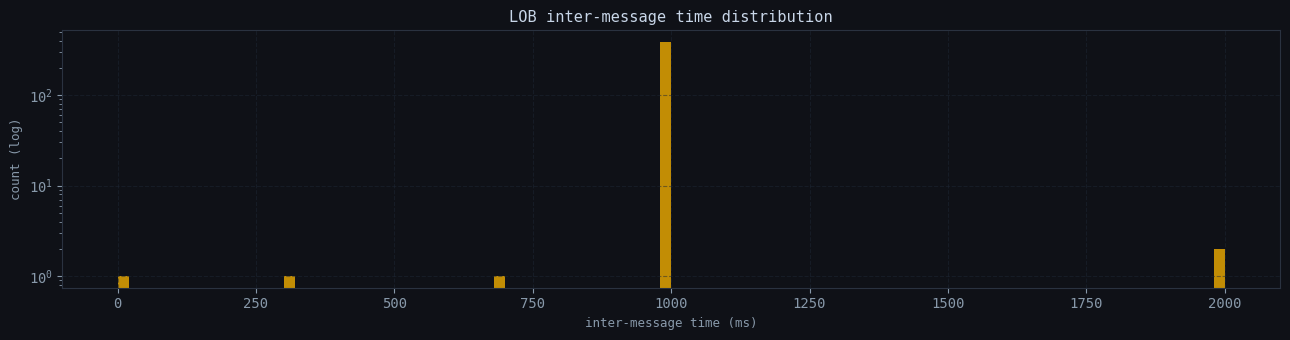

In [22]:
lob_sorted = lob[lob['exchHostTime'] > 0].sort_values('exchHostTime').copy()
lob_sorted['dt_ms'] = lob_sorted['exchHostTime'].diff() / 1e6  # milliseconds

dt_pos = lob_sorted['dt_ms'][lob_sorted['dt_ms'] > 0]
print("Inter-message time (ms) stats:")
print(dt_pos.describe().to_string())
print()

# Suspicious gaps
gap_threshold_ms = 1000  # 1 second
big_gaps = lob_sorted[lob_sorted['dt_ms'] > gap_threshold_ms]
print(f"Gaps > {gap_threshold_ms} ms between LOB updates: {len(big_gaps)}")
print()
print(big_gaps[['exchHostTime','dt_ms']].head(10).to_string())

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.hist(dt_pos[dt_pos < 5000], bins=100, color='#ffb800', alpha=0.75, edgecolor='none')
ax.set_yscale('log')
ax.set_xlabel('inter-message time (ms)')
ax.set_ylabel('count (log)')
ax.set_title('LOB inter-message time distribution')
ax.grid(True)
plt.tight_layout()
plt.show()

## 17. Field Domain Checks (type, moreTradesInBatch)

In [23]:
print("=== type field values ===")
print(df['type'].value_counts().to_string())
unexpected_type = df[~df['type'].isin([4, 6])]
print(f"Rows with type not in {{4, 6}}: {len(unexpected_type)}  {'⚠' if len(unexpected_type) > 0 else '✓'}")

print()
print("=== moreTradesInBatch values ===")
print(df['moreTradesInBatch'].value_counts(dropna=False).to_string())
unexpected_batch = df[~df['moreTradesInBatch'].isin([0, 1]) & df['moreTradesInBatch'].notna()]
print(f"Values outside {{0, 1, NaN}}: {len(unexpected_batch)}  {'⚠' if len(unexpected_batch) > 0 else '✓'}")

print()
print("=== trade_cnt range ===")
print(f"Min: {df['trade_cnt'].min()}  Max: {df['trade_cnt'].max()}")
print(f"Negative trade_cnt: {(df['trade_cnt'] < 0).sum()}  ⚠")

=== type field values ===
type
6    30156
4    10218
Rows with type not in {4, 6}: 0  ✓

=== moreTradesInBatch values ===
moreTradesInBatch
NaN    30156
0.0    10218
Values outside {0, 1, NaN}: 0  ✓

=== trade_cnt range ===
Min: -1  Max: 46
Negative trade_cnt: 1  ⚠


## 18. Bid/Ask Volume Imbalance

Bid/Ask volume imbalance stats (−1=all ask, +1=all bid):
count    30153.000000
mean         0.008613
std          0.598476
min         -1.000000
25%         -0.557798
50%          0.046318
75%          0.586095
max          1.000000

Rows with |imbalance| > 0.99: 6  ⚠


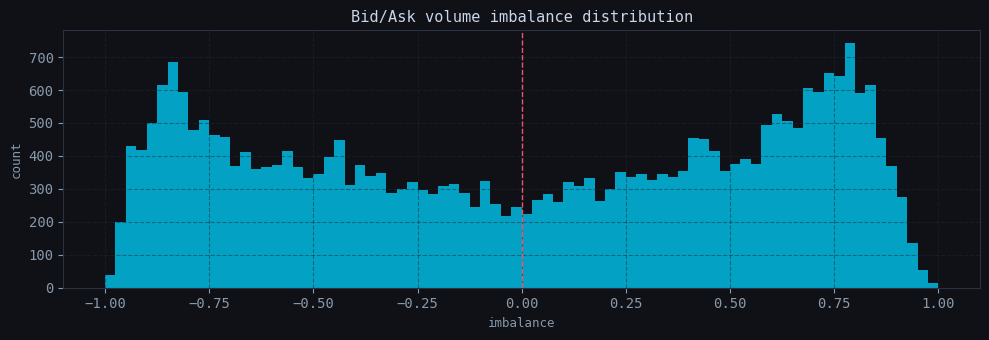

In [24]:
lob_valid = lob[(lob['px_buy_1'] > 100) & (lob['px_buy_1'] < 1e6)].copy()

amt_buy_cols  = [f'amt_buy_{i}'  for i in range(1, 11)]
amt_sell_cols = [f'amt_sell_{i}' for i in range(1, 11)]

lob_valid['total_bid'] = lob_valid[amt_buy_cols].clip(lower=0).sum(axis=1)
lob_valid['total_ask'] = lob_valid[amt_sell_cols].clip(lower=0).sum(axis=1)
lob_valid['imbalance'] = (lob_valid['total_bid'] - lob_valid['total_ask']) /                          (lob_valid['total_bid'] + lob_valid['total_ask'] + 1e-9)

print("Bid/Ask volume imbalance stats (−1=all ask, +1=all bid):")
print(lob_valid['imbalance'].describe().to_string())
print()
extreme = lob_valid[lob_valid['imbalance'].abs() > 0.99]
print(f"Rows with |imbalance| > 0.99: {len(extreme)}  ⚠")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(lob_valid['imbalance'], bins=80, color='#00d4ff', alpha=0.75, edgecolor='none')
ax.set_xlabel('imbalance')
ax.set_ylabel('count')
ax.set_title('Bid/Ask volume imbalance distribution')
ax.axvline(0, color='#ff4d6d', lw=1, ls='--')
ax.grid(True)
plt.tight_layout()
plt.show()

## 19. Duplicate Trades Across Two Feed Clusters (122M vs 173M)

In [25]:
t1 = trades[trades['msgSeqNum'] < 1.5e8].copy()  # cluster 122M
t2 = trades[trades['msgSeqNum'] > 1.5e8].copy()  # cluster 173M

print(f"Cluster 122M: {len(t1):,} rows")
print(f"Cluster 173M: {len(t2):,} rows")

# Match on (exchHostTime, trade_px, trade_amt)
key_cols = ['exchHostTime', 'trade_px', 'trade_amt']
merged_feeds = pd.merge(
    t1[key_cols + ['msgSeqNum']].rename(columns={'msgSeqNum': 'seq1'}),
    t2[key_cols + ['msgSeqNum']].rename(columns={'msgSeqNum': 'seq2'}),
    on=key_cols
)
print(f"\nExact matches (same time + px + amt in both feeds): {len(merged_feeds):,}  ⚠")
print()
print(merged_feeds.head(10).to_string())

Cluster 122M: 3,930 rows
Cluster 173M: 6,288 rows

Exact matches (same time + px + amt in both feeds): 3,131  ⚠

          exchHostTime  trade_px  trade_amt       seq1       seq2
0  1596240037000000000  11358.25      0.175  122537841  173525833
1  1596240037000000000  11358.26      2.000  122537842  173525834
2  1596240037000000000  11358.33      0.004  122537843  173525835
3  1596240037000000000  11358.35      0.001  122537844  173525836
4  1596240037000000000  11358.82      0.001  122537845  173525837
5  1596240037000000000  11359.31      1.008  122537848  173525843
6  1596240037000000000  11357.99     -0.001  122537851  173525848
7  1596240037000000000  11359.36     -0.015  122537854  173525853
8  1596240037000000000  11359.37      0.001  122537855  173525854
9  1596240037000000000  11359.40      0.020  122537856  173525855


## 20. Ghost Trades (trade_cnt = 0)

trade_cnt == 0 rows: 6,288
trade_cnt  > 0 rows: 3,930

trade_px stats for trade_cnt == 0:
count     6288.000000
mean     11347.594913
std         35.433421
min      11293.270000
25%      11309.010000
50%      11366.020000
75%      11380.320000
max      11392.800000

trade_px stats for trade_cnt > 0:
count     3930.000000
mean     11347.887443
std         35.158544
min      11293.270000
25%      11309.170000
50%      11366.660000
75%      11380.600000
max      11392.800000

Mean |px - prev_px| for ghost trades: 0.2764
Mean |px - prev_px| for real  trades: 0.3678


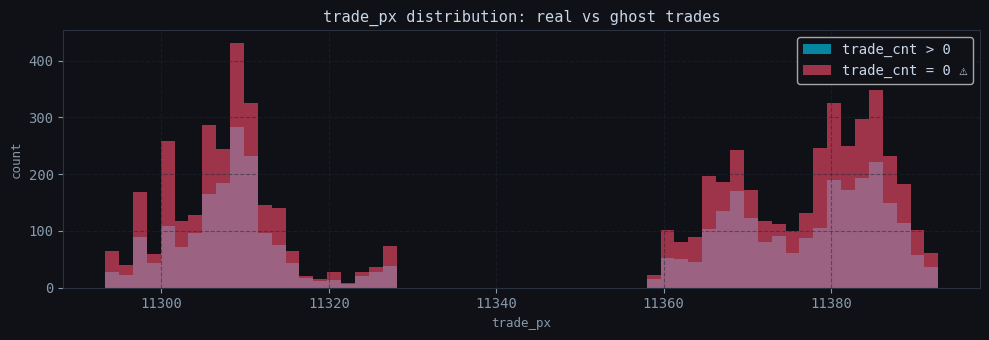

In [26]:
zero_cnt = trades[trades['trade_cnt'] == 0].copy()
nonzero_cnt = trades[trades['trade_cnt'] > 0].copy()

print(f"trade_cnt == 0 rows: {len(zero_cnt):,}")
print(f"trade_cnt  > 0 rows: {len(nonzero_cnt):,}")
print()

# Are trade_px values in zero_cnt the same distribution as real trades?
print("trade_px stats for trade_cnt == 0:")
print(zero_cnt['trade_px'].describe().to_string())
print()
print("trade_px stats for trade_cnt > 0:")
print(nonzero_cnt['trade_px'].describe().to_string())
print()

# Do zero_cnt rows have the same px as adjacent rows?
trades_sorted = trades.sort_values('exchHostTime').reset_index(drop=True)
trades_sorted['px_diff_prev'] = (trades_sorted['trade_px'] - trades_sorted['trade_px'].shift(1)).abs()
ghost = trades_sorted[trades_sorted['trade_cnt'] == 0]
print(f"Mean |px - prev_px| for ghost trades: {ghost['px_diff_prev'].mean():.4f}")
print(f"Mean |px - prev_px| for real  trades: {trades_sorted[trades_sorted['trade_cnt']>0]['px_diff_prev'].mean():.4f}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(nonzero_cnt['trade_px'], bins=60, color='#00d4ff', alpha=0.6, label='trade_cnt > 0')
ax.hist(zero_cnt['trade_px'],    bins=60, color='#ff4d6d', alpha=0.6, label='trade_cnt = 0 ⚠')
ax.set_xlabel('trade_px'); ax.set_ylabel('count')
ax.set_title('trade_px distribution: real vs ghost trades')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

## 21. Identical Consecutive LOB Snapshots

In [27]:
lob_check_cols = ['px_buy_1','px_sell_1','amt_buy_1','amt_sell_1',
                  'px_buy_2','px_sell_2']
lob_sorted = lob.sort_values('exchHostTime').reset_index(drop=True)

# Compare each row with previous
identical_mask = (lob_sorted[lob_check_cols] == lob_sorted[lob_check_cols].shift(1)).all(axis=1)
identical_count = identical_mask.sum()

print(f"Consecutive identical LOB snapshots (same top-2 levels): {identical_count:,}")
print(f"As % of total LOB rows: {identical_count/len(lob)*100:.1f}%")
print()

# Are they at same or different exchHostTime?
ident_rows = lob_sorted[identical_mask]
same_ts = (ident_rows['exchHostTime'] == lob_sorted['exchHostTime'].shift(1)[identical_mask]).sum()
print(f"  Of those, same exchHostTime as previous: {same_ts:,}")
print(f"  Different exchHostTime (true duplicates): {identical_count - same_ts:,}  ⚠")

Consecutive identical LOB snapshots (same top-2 levels): 7,281
As % of total LOB rows: 24.1%

  Of those, same exchHostTime as previous: 7,281
  Different exchHostTime (true duplicates): 0  ⚠


## 22. trade_cnt > 1 Without Batch Neighbours

In [28]:
trades_s = trades.sort_values('exchHostTime').reset_index(drop=True)

# For rows with trade_cnt > 1, check if there's another trade row at same exchHostTime
multi = trades_s[trades_s['trade_cnt'] > 1].copy()
ts_counts = trades_s.groupby('exchHostTime').size()
multi['n_trades_same_ts'] = multi['exchHostTime'].map(ts_counts)

isolated = multi[multi['n_trades_same_ts'] == 1]
print(f"trade_cnt > 1 rows: {len(multi):,}")
print(f"Of those, isolated (only 1 trade row at that exchHostTime): {len(isolated):,}  ⚠")
print()
print(isolated[['exchHostTime','trade_px','trade_amt','trade_cnt','n_trades_same_ts']].head(10).to_string())

trade_cnt > 1 rows: 1,131
Of those, isolated (only 1 trade row at that exchHostTime): 1  ⚠

             exchHostTime  trade_px  trade_amt  trade_cnt  n_trades_same_ts
5857  1596241207000000000  11327.87      0.004          3                 1


## 23. trade_amt vs Available Volume at Best Level

In [29]:
lob_ts = lob[lob['exchHostTime'] > 0][['exchHostTime','amt_buy_1','amt_sell_1']].copy()
lob_ts = lob_ts[(lob_ts['amt_buy_1'] > 0) & (lob_ts['amt_buy_1'] < 1e6)].sort_values('exchHostTime')

trades_ts = trades[trades['exchHostTime'] > 0].sort_values('exchHostTime')

merged = pd.merge_asof(
    trades_ts[['exchHostTime','trade_amt','trade_px']],
    lob_ts,
    on='exchHostTime',
    direction='backward'
).dropna()

merged['abs_amt'] = merged['trade_amt'].abs()
merged['exceeds_best'] = merged['abs_amt'] > merged[['amt_buy_1','amt_sell_1']].max(axis=1)

print(f"Trades where |trade_amt| > max(amt_buy_1, amt_sell_1): {merged['exceeds_best'].sum():,}")
print()
print("Stats for exceeding trades:")
print(merged[merged['exceeds_best']][['trade_amt','amt_buy_1','amt_sell_1']].describe().to_string())

Trades where |trade_amt| > max(amt_buy_1, amt_sell_1): 742

Stats for exceeding trades:
        trade_amt   amt_buy_1  amt_sell_1
count  742.000000  742.000000  742.000000
mean    -0.145887    0.416557    0.411208
std      3.329835    0.859766    1.002597
min    -25.246000    0.001000    0.001000
25%     -0.916750    0.059000    0.065000
50%      0.145000    0.116000    0.174500
75%      1.002000    0.468000    0.430000
max     14.275000    8.390000   12.219000


## 24. adapterTime Duplicates and Zero-Gaps

adapterTime duplicates: 100

adapterTime zero-gap (same timestamp for consecutive messages): 100  ⚠

adapterTime inter-message gap (µs) stats:
count    4.027300e+04
mean     3.399649e+04
std      4.045375e+06
min      1.000000e-03
25%      2.337400e+02
50%      4.749098e+03
75%      8.798659e+03
max      8.014142e+08


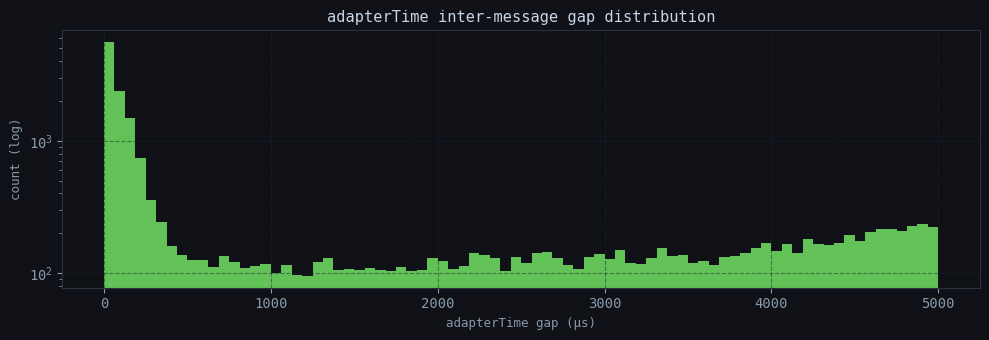

In [30]:
print(f"adapterTime duplicates: {df['adapterTime'].duplicated().sum():,}")
print()

df_sorted = df.sort_values('adapterTime').reset_index(drop=True)
df_sorted['adt_diff_us'] = df_sorted['adapterTime'].diff() / 1000

zero_gap = (df_sorted['adt_diff_us'] == 0).sum()
print(f"adapterTime zero-gap (same timestamp for consecutive messages): {zero_gap:,}  ⚠")
print()

# Distribution of adapterTime gaps
adt_pos = df_sorted['adt_diff_us'][df_sorted['adt_diff_us'] > 0]
print("adapterTime inter-message gap (µs) stats:")
print(adt_pos.describe().to_string())

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(adt_pos[adt_pos < 5000], bins=80, color='#7fff6e', alpha=0.75, edgecolor='none')
ax.set_yscale('log')
ax.set_xlabel('adapterTime gap (µs)')
ax.set_ylabel('count (log)')
ax.set_title('adapterTime inter-message gap distribution')
ax.grid(True)
plt.tight_layout()
plt.show()

## 25. exchHostTime Anomaly Taxonomy

In [31]:
valid_ts = df[df['exchHostTime'] > 0].copy()

# Sub-second rows
sub_sec = valid_ts[valid_ts['exchHostTime'] % 1_000_000_000 != 0]
print(f"exchHostTime with sub-second precision: {len(sub_sec)} rows")
print()
print(sub_sec[['type','msgSeqNum','exchHostTime','adapterTime']].to_string())

print()
print("--- Analysis ---")
for _, row in sub_sec.iterrows():
    ts = row['exchHostTime']
    n_digits = len(str(ts))
    print(f"  ts={ts}  digits={n_digits}", end='')
    if n_digits == 18:
        print(f"  ⚠ 18 digits — missing leading digit! Should be: 1{ts}")
    elif ts % 1_000_000_000 == 100_000:
        print(f"  ⚠ +100µs offset from second boundary")
    else:
        print(f"  ⚠ sub-second value")

exchHostTime with sub-second precision: 4 rows

       type    msgSeqNum         exchHostTime          adapterTime
16630     6  45254037596  1596240342000100000  1596240342915858653
20070     4    173531151  1596240388390693885  1596240388000000000
27858     6  45257504478  1596241260691956680  1596241260000000000
37497     6  45257872839   159624135400000000  1596241354538738865

--- Analysis ---
  ts=1596240342000100000  digits=19  ⚠ +100µs offset from second boundary
  ts=1596240388390693885  digits=19  ⚠ sub-second value
  ts=1596241260691956680  digits=19  ⚠ sub-second value
  ts=159624135400000000  digits=18  ⚠ 18 digits — missing leading digit! Should be: 1159624135400000000


## 26. px_sell_9 and px_sell_10 — Systematic Ratio to px_sell_1

px_sell_9 / px_sell_1:
count    30156.000000
mean         1.100133
std          0.000052
min          1.099893
25%          1.100095
50%          1.100132
75%          1.100169
max          1.100450

  → mean ≈ 1.1001  (very close to ×1.1)

px_sell_10 / px_sell_1:
count    30156.000000
mean         1.210147
std          0.000057
min          1.209882
25%          1.210105
50%          1.210146
75%          1.210185
max          1.210496

  → mean ≈ 1.2101  (very close to ×1.21 = 1.1²)


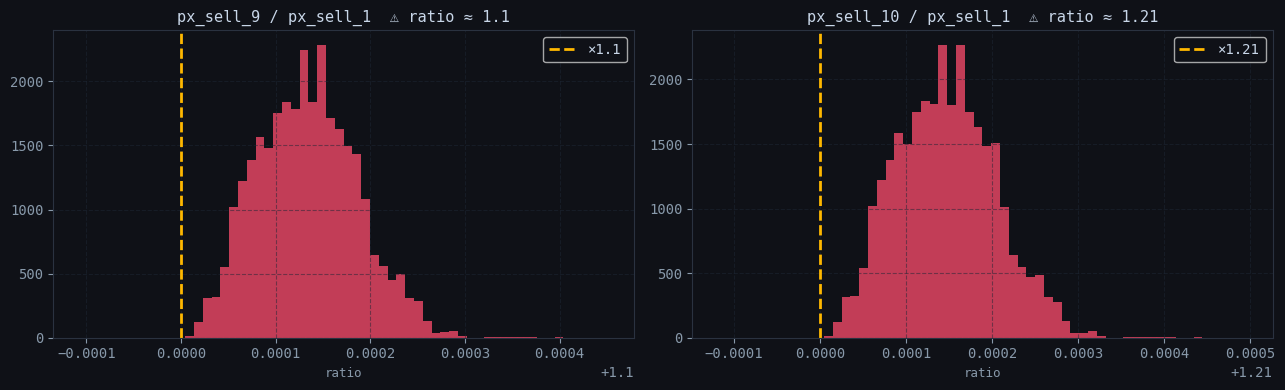

In [32]:
ratio9  = lob['px_sell_9']  / lob['px_sell_1']
ratio10 = lob['px_sell_10'] / lob['px_sell_1']

print("px_sell_9 / px_sell_1:")
print(ratio9.describe().to_string())
print(f"\n  → mean ≈ 1.1001  (very close to ×1.1)")

print()
print("px_sell_10 / px_sell_1:")
print(ratio10.describe().to_string())
print(f"\n  → mean ≈ 1.2101  (very close to ×1.21 = 1.1²)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(ratio9,  bins=60, color='#ff4d6d', alpha=0.75)
axes[0].axvline(1.1, color='#ffb800', lw=2, ls='--', label='×1.1')
axes[0].set_title('px_sell_9 / px_sell_1  ⚠ ratio ≈ 1.1')
axes[0].set_xlabel('ratio'); axes[0].legend(); axes[0].grid(True)

axes[1].hist(ratio10, bins=60, color='#ff4d6d', alpha=0.75)
axes[1].axvline(1.21, color='#ffb800', lw=2, ls='--', label='×1.21')
axes[1].set_title('px_sell_10 / px_sell_1  ⚠ ratio ≈ 1.21')
axes[1].set_xlabel('ratio'); axes[1].legend(); axes[1].grid(True)
px_sell_9 / px_sell_1:
count    30156.000000
mean         1.100133
std          0.000052
min          1.099893
25%          1.100095
50%          1.100132
75%          1.100169
max          1.100450

  → mean ≈ 1.1001  (very close to ×1.1)

px_sell_10 / px_sell_1:
count    30156.000000
mean         1.210147
std          0.000057
min          1.209882
25%          1.210105
50%          1.210146
75%          1.210185
max          1.210496

  → mean ≈ 1.2101  (very close to ×1.21 = 1.1²)
plt.tight_layout()
plt.show()

## 27. Partial LOB Snapshot (Missing Levels)

In [33]:
lob2 = lob.copy()
lob2['n_buy_levels']  = lob2[[f'px_buy_{i}'  for i in range(1,11)]].notna().sum(axis=1)
lob2['n_sell_levels'] = lob2[[f'px_sell_{i}' for i in range(1,11)]].notna().sum(axis=1)

print("Buy level count distribution:")
print(lob2['n_buy_levels'].value_counts().sort_index().to_string())
print()
print("Sell level count distribution:")
print(lob2['n_sell_levels'].value_counts().sort_index().to_string())

partial_buy = lob2[lob2['n_buy_levels'] < 10]
print(f"\nRows with < 10 buy levels: {len(partial_buy)}  ⚠")
print()
print(partial_buy[[f'px_buy_{i}' for i in range(1,11)]].to_string())
print()
print(partial_buy[['exchHostTime','px_sell_1','amt_sell_1']].to_string())

Buy level count distribution:
n_buy_levels
9         1
10    30155

Sell level count distribution:
n_sell_levels
10    30156

Rows with < 10 buy levels: 1  ⚠

      px_buy_1  px_buy_2  px_buy_3  px_buy_4  px_buy_5  px_buy_6  px_buy_7  px_buy_8  px_buy_9  px_buy_10
5212       NaN  11367.93  11367.92  11367.91   11367.9   11367.8  11367.79  11367.38  11367.37   11367.13

             exchHostTime  px_sell_1  amt_sell_1
5212  1596240060000000000   11370.05       0.249


## 28. Row with All amt_buy_* = NaN (Bid Side Amounts Missing)

In [34]:
nan_amt_row = df[df['amt_buy_1'].isna()]
print(f"Rows with amt_buy_1 = NaN: {len(nan_amt_row)}")
print()
print("px_buy columns:")
print(nan_amt_row[[f'px_buy_{i}'  for i in range(1,11)]].to_string())
print()
print("amt_buy columns:")
print(nan_amt_row[[f'amt_buy_{i}' for i in range(1,11)]].to_string())
print()
print("amt_sell columns:")
print(nan_amt_row[[f'amt_sell_{i}' for i in range(1,11)]].to_string())
print()
print("  ⚠ Prices filled, sell amounts filled, but ALL 10 bid amounts = NaN")
print("  → Partial snapshot: bid side quantities completely missing")

Rows with amt_buy_1 = NaN: 1

px_buy columns:
       px_buy_1  px_buy_2  px_buy_3  px_buy_4  px_buy_5  px_buy_6  px_buy_7  px_buy_8  px_buy_9  px_buy_10
18932  11380.32   11380.0   11379.1  11379.09  11379.08  11378.91  11378.82  11378.79  11378.58    11378.5

amt_buy columns:
       amt_buy_1  amt_buy_2  amt_buy_3  amt_buy_4  amt_buy_5  amt_buy_6  amt_buy_7  amt_buy_8  amt_buy_9  amt_buy_10
18932        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN         NaN

amt_sell columns:
       amt_sell_1  amt_sell_2  amt_sell_3  amt_sell_4  amt_sell_5  amt_sell_6  amt_sell_7  amt_sell_8  amt_sell_9  amt_sell_10
18932       0.485         7.2       1.076        0.12        0.06         0.3         0.9         1.0         1.1        0.836

  ⚠ Prices filled, sell amounts filled, but ALL 10 bid amounts = NaN
  → Partial snapshot: bid side quantities completely missing


## 29. px_buy_9 Sign Flip (Negated Price)

Rows with px_buy_9 < 0: 1

       px_buy_7  px_buy_8  px_buy_9  px_buy_10
10511  11384.31  11384.22 -11384.15   11384.13

  px_buy_8  = 11384.22
  px_buy_9  = -11384.15  ⚠ sign flipped — magnitude matches px_buy_8
  px_buy_10 =  11384.13

  → Isolated sign error on one level, value otherwise plausible


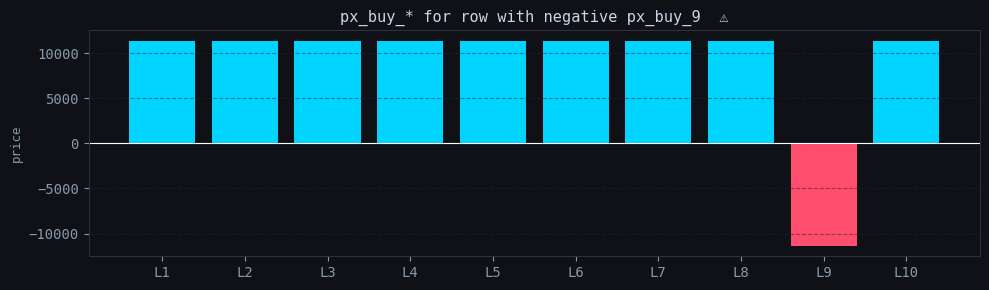

In [35]:
neg_row = lob[lob['px_buy_9'] < 0]
print(f"Rows with px_buy_9 < 0: {len(neg_row)}")
print()
print(neg_row[[f'px_buy_{i}' for i in range(7,11)]].to_string())
print()
print("  px_buy_8  = 11384.22")
print("  px_buy_9  = -11384.15  ⚠ sign flipped — magnitude matches px_buy_8")
print("  px_buy_10 =  11384.13")
print()
print("  → Isolated sign error on one level, value otherwise plausible")

fig, ax = plt.subplots(figsize=(10, 3))
levels = [f'px_buy_{i}' for i in range(1,11)]
vals = neg_row[levels].iloc[0].values
ax.bar(range(1,11), vals, color=['#ff4d6d' if v < 0 else '#00d4ff' for v in vals])
ax.axhline(0, color='white', lw=0.8)
ax.set_xticks(range(1,11)); ax.set_xticklabels([f'L{i}' for i in range(1,11)])
ax.set_title('px_buy_* for row with negative px_buy_9  ⚠')
ax.set_ylabel('price'); ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 30. Truncated exchHostTime (18 digits instead of 19)

In [36]:
short_ts = df[df['exchHostTime'].astype(str).str.len() == 18]
print(f"Rows with 18-digit exchHostTime (missing leading digit): {len(short_ts)}")
print()
print(short_ts[['type','msgSeqNum','exchHostTime','adapterTime','px_buy_1','px_sell_1']].to_string())
print()
print(f"  Actual:   159624135400000000  (18 digits)")
print(f"  Expected: 1596241354000000000 (19 digits)")
print(f"  → Off by factor of 10, placing timestamp in year ~1975 instead of 2020")

import datetime
wrong_dt = datetime.datetime.fromtimestamp(159624135400000000 / 1e9)
right_dt = datetime.datetime.fromtimestamp(1596241354000000000 / 1e9)
print(f"\n  Wrong interpretation: {wrong_dt}")
print(f"  Correct (×10):        {right_dt}")

Rows with 18-digit exchHostTime (missing leading digit): 1

       type    msgSeqNum        exchHostTime          adapterTime  px_buy_1  px_sell_1
37497     6  45257872839  159624135400000000  1596241354538738865  11303.19    11303.2

  Actual:   159624135400000000  (18 digits)
  Expected: 1596241354000000000 (19 digits)
  → Off by factor of 10, placing timestamp in year ~1975 instead of 2020

  Wrong interpretation: 1975-01-22 15:02:15.400000
  Correct (×10):        2020-08-01 03:22:34


## 31. Zero Volume at LOB Level (amt_buy_6 = 0)

In [37]:
zero_vol = lob[lob['amt_buy_6'] == 0]
print(f"Rows with amt_buy_6 == 0: {len(zero_vol)}")
print()
print(zero_vol[['exchHostTime'] + [f'amt_buy_{i}' for i in range(4,9)] + [f'px_buy_{i}' for i in range(4,9)]].to_string())
print()
print("  ⚠ Price is present (11293.15) but amount = 0")
print("  → Level exists in price ladder but has no orders — should be absent or removed")

Rows with amt_buy_6 == 0: 1

              exchHostTime  amt_buy_4  amt_buy_5  amt_buy_6  amt_buy_7  amt_buy_8  px_buy_4  px_buy_5  px_buy_6  px_buy_7  px_buy_8
33848  1596241322000000000       0.04        0.3        0.0      0.025      0.018   11293.2  11293.16  11293.15   11293.1  11293.02

  ⚠ Price is present (11293.15) but amount = 0
  → Level exists in price ladder but has no orders — should be absent or removed


## 32. Feed Duplication: 3131 Trades Appear in Both Clusters

Cluster 122M total: 3,930
Cluster 173M total: 6,288
Exact duplicates (same exchHostTime + trade_px + trade_amt): 3,131  ⚠
  = 79.7% of cluster 122M are duplicates of 173M

          exchHostTime  trade_px  trade_amt   seq_122M   seq_173M
0  1596240037000000000  11358.25      0.175  122537841  173525833
1  1596240037000000000  11358.26      2.000  122537842  173525834
2  1596240037000000000  11358.33      0.004  122537843  173525835
3  1596240037000000000  11358.35      0.001  122537844  173525836
4  1596240037000000000  11358.82      0.001  122537845  173525837
5  1596240037000000000  11359.31      1.008  122537848  173525843
6  1596240037000000000  11357.99     -0.001  122537851  173525848
7  1596240037000000000  11359.36     -0.015  122537854  173525853


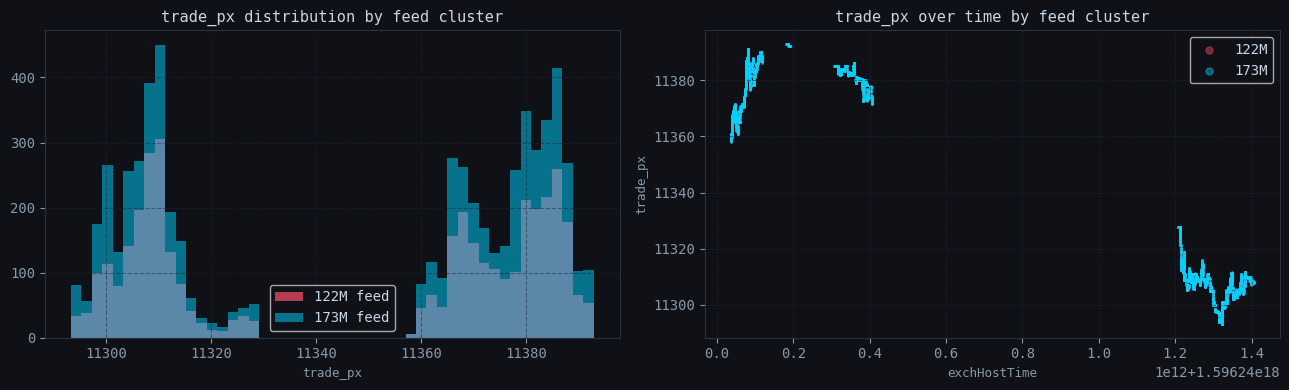

In [38]:
t1 = trades[trades['msgSeqNum'] < 1.5e8].copy()
t2 = trades[trades['msgSeqNum'] > 1.5e8].copy()

key_cols = ['exchHostTime', 'trade_px', 'trade_amt']
dup_trades = pd.merge(
    t1[key_cols + ['msgSeqNum']].rename(columns={'msgSeqNum': 'seq_122M'}),
    t2[key_cols + ['msgSeqNum']].rename(columns={'msgSeqNum': 'seq_173M'}),
    on=key_cols
)

print(f"Cluster 122M total: {len(t1):,}")
print(f"Cluster 173M total: {len(t2):,}")
print(f"Exact duplicates (same exchHostTime + trade_px + trade_amt): {len(dup_trades):,}  ⚠")
print(f"  = {len(dup_trades)/len(t1)*100:.1f}% of cluster 122M are duplicates of 173M")
print()
print(dup_trades.head(8).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(t1['trade_px'], bins=50, color='#ff4d6d', alpha=0.7, label='122M feed')
axes[0].hist(t2['trade_px'], bins=50, color='#00d4ff', alpha=0.5, label='173M feed')
axes[0].set_title('trade_px distribution by feed cluster')
axes[0].set_xlabel('trade_px'); axes[0].legend(); axes[0].grid(True)

axes[1].scatter(t1['exchHostTime'], t1['trade_px'], s=1, alpha=0.4, color='#ff4d6d', label='122M')
axes[1].scatter(t2['exchHostTime'], t2['trade_px'], s=1, alpha=0.4, color='#00d4ff', label='173M')
axes[1].set_title('trade_px over time by feed cluster')
axes[1].set_xlabel('exchHostTime'); axes[1].set_ylabel('trade_px')
axes[1].legend(markerscale=5); axes[1].grid(True)

plt.tight_layout()
plt.show()

## 33. exchHostTime Rounded to Second (99.99% of rows)

exchHostTime rounded to second:    40,369  (99.99%)
exchHostTime with sub-second info: 4  (0.01%)

  adapterTime granularity (for comparison):
  adapterTime rounded to second: 2  (0.005%)

  ⚠ exchHostTime loses all sub-second precision — makes LOB ordering
    within the same second ambiguous and inter-message gaps meaningless.


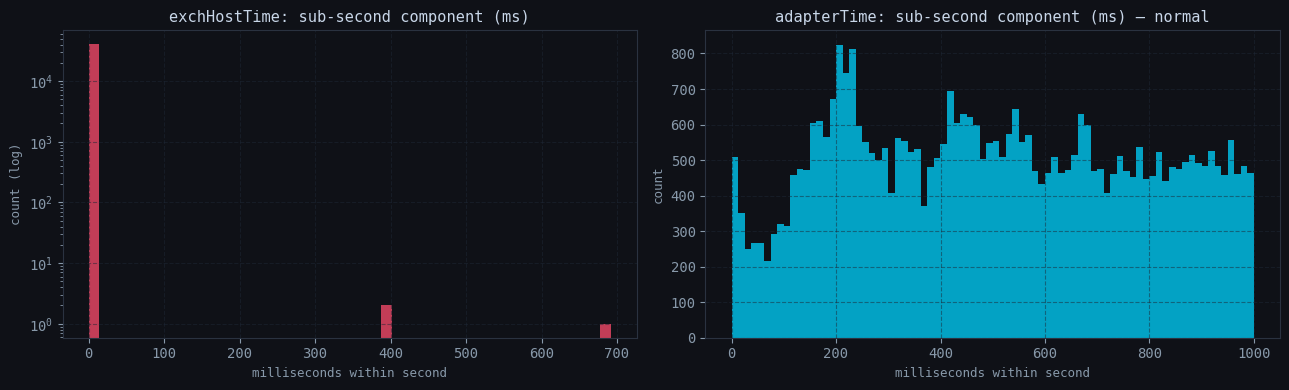

In [39]:
valid_ts = df[df['exchHostTime'] > 0].copy()
n_second = (valid_ts['exchHostTime'] % 1_000_000_000 == 0).sum()
n_subsec  = (valid_ts['exchHostTime'] % 1_000_000_000 != 0).sum()

print(f"exchHostTime rounded to second:    {n_second:,}  ({n_second/len(valid_ts)*100:.2f}%)")
print(f"exchHostTime with sub-second info: {n_subsec:,}  ({n_subsec/len(valid_ts)*100:.2f}%)")
print()
print("  adapterTime granularity (for comparison):")
n_adt_sec = (df['adapterTime'] % 1_000_000_000 == 0).sum()
print(f"  adapterTime rounded to second: {n_adt_sec:,}  ({n_adt_sec/len(df)*100:.3f}%)")
print()
print("  ⚠ exchHostTime loses all sub-second precision — makes LOB ordering")
print("    within the same second ambiguous and inter-message gaps meaningless.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# exchHostTime sub-second part
sub_part = valid_ts['exchHostTime'] % 1_000_000_000
axes[0].hist(sub_part / 1e6, bins=50, color='#ff4d6d', alpha=0.75)
axes[0].set_title('exchHostTime: sub-second component (ms)')
axes[0].set_xlabel('milliseconds within second')
axes[0].set_ylabel('count (log)')
axes[0].set_yscale('log')
axes[0].grid(True)

# adapterTime sub-second part
adt_sub = df['adapterTime'] % 1_000_000_000
axes[1].hist(adt_sub / 1e6, bins=80, color='#00d4ff', alpha=0.75)
axes[1].set_title('adapterTime: sub-second component (ms) — normal')
axes[1].set_xlabel('milliseconds within second')
axes[1].set_ylabel('count')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 34. Full Error Summary (Updated)

In [40]:
errors = [
    # dtype / structural
    ("px_sell_7 dtype = str instead of float64",                        "CRITICAL", "all rows"),
    ("exchHostTime rounded to second — sub-second precision lost",      "CRITICAL", "99.99% of rows"),
    ("px_sell_9 = px_sell_1 × 1.1, px_sell_10 = px_sell_1 × 1.21",    "CRITICAL", "all LOB rows"),
    ("amt_buy_* max up to 12.6B (ask max ~78) — bid scale error",       "CRITICAL", "1 row per level"),
    ("Bid prices ×10⁶ (1.137e10 vs ~11374) — entire bid side",         "CRITICAL", "1 row"),
    # duplicates
    ("101 identical duplicate rows, msgSeqNum=173531184",               "CRITICAL", "101 rows"),
    ("3131/3930 trades in cluster 122M are exact duplicates of 173M",   "CRITICAL", "3131 rows"),
    # trade fields
    ("trade_amt negative",                                              "CRITICAL", "4937 rows"),
    ("trade_cnt = 0 in trade events with non-null price/amt",           "CRITICAL", "6288 rows"),
    ("trade_cnt = -1",                                                  "WARN",     "1 row"),
    ("moreTradesInBatch always 0 despite trade_cnt > 1",                "WARN",     "1131 rows"),
    ("Isolated trade_cnt=3 row with no batch neighbours",               "WARN",     "1 row"),
    # LOB price errors
    ("Crossed book: best bid >= best ask",                              "CRITICAL", "3 rows"),
    ("Locked market: best bid == best ask",                             "WARN",     "2 rows"),
    ("px_buy_9 sign-flipped (negated value: -11384.15)",                "CRITICAL", "1 row"),
    ("px_buy_1 = 0",                                                    "WARN",     "1 row"),
    ("px_buy_1 = NaN — missing best bid",                               "WARN",     "1 row"),
    ("All 10 amt_buy_* = NaN — entire bid-side amounts missing",        "WARN",     "1 row"),
    ("amt_buy_6 = 0 — price present but zero volume at level",         "WARN",     "1 row"),
    ("Negative LOB amounts (amt_buy_*, amt_sell_8)",                    "WARN",     "12 rows"),
    ("Ask levels not ascending (inverted order)",                       "WARN",     "1 row"),
    # timestamps
    ("exchHostTime = 0",                                                "WARN",     "1 row"),
    ("exchHostTime 18 digits — missing leading digit (year ~1975)",     "CRITICAL", "1 row"),
    ("exchHostTime +100µs offset from second boundary",                 "WARN",     "1 row"),
    ("adapterTime < exchHostTime — causality violation",                "WARN",     "2 rows"),
    ("adapterTime rounded to second on the 2 negative-latency rows",    "WARN",     "2 rows"),
    ("Systematic latency ~528ms — implausible for HFT co-location",     "WARN",     "all rows"),
    ("Out-of-order exchHostTime within same feed",                      "WARN",     "4 LOB + 50 trades"),
    # sequence
    ("Two seqnum ranges in trades (122M / 173M) — mixed feeds",        "INFO",     "2 clusters"),
    ("Large LOB seqnum gaps (up to 2.9M missing msgs)",                 "WARN",     "30129 gaps"),
    ("Large time gaps in LOB: 60s, 115s, 802s",                        "WARN",     "3 gaps"),
    # cross-field
    ("Trade fields = 0.0 in LOB rows instead of NaN",                  "INFO",     "30156 rows"),
    ("LOB fields filled in trade rows",                                 "INFO",     "10218 rows"),
    ("Partial LOB snapshot: px_buy_1=NaN, levels 2-10 present",        "WARN",     "1 row"),
]

print(f"{'#':<4} {'Error':<58} {'Severity':<10} {'Scope'}")
print("─" * 95)
for i, (desc, sev, cnt) in enumerate(errors, 1):
    marker = '⚠ ' if sev == 'CRITICAL' else '  '
    print(f"{i:<4} {marker}{desc:<56} {sev:<10} {cnt}")
print()
print(f"Total distinct error types: {len(errors)}")

#    Error                                                      Severity   Scope
───────────────────────────────────────────────────────────────────────────────────────────────
1    ⚠ px_sell_7 dtype = str instead of float64                 CRITICAL   all rows
2    ⚠ exchHostTime rounded to second — sub-second precision lost CRITICAL   99.99% of rows
3    ⚠ px_sell_9 = px_sell_1 × 1.1, px_sell_10 = px_sell_1 × 1.21 CRITICAL   all LOB rows
4    ⚠ amt_buy_* max up to 12.6B (ask max ~78) — bid scale error CRITICAL   1 row per level
5    ⚠ Bid prices ×10⁶ (1.137e10 vs ~11374) — entire bid side   CRITICAL   1 row
6    ⚠ 101 identical duplicate rows, msgSeqNum=173531184        CRITICAL   101 rows
7    ⚠ 3131/3930 trades in cluster 122M are exact duplicates of 173M CRITICAL   3131 rows
8    ⚠ trade_amt negative                                       CRITICAL   4937 rows
9    ⚠ trade_cnt = 0 in trade events with non-null price/amt    CRITICAL   6288 rows
10     trade_cnt = -1                   